In [42]:
import math
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

### Задание 1

In [43]:
def f(x):
    """Функция f(x) = 3*sin(8x) - 0.7x + 0.9"""
    return 3 * math.sin(8 * x) - 0.7 * x + 0.9

--- Отделение корней на отрезке [-1, 1] ---


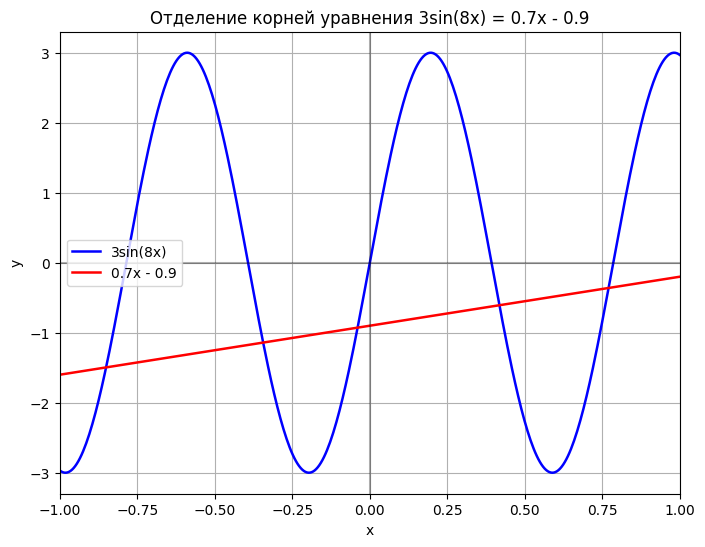

Корень на отрезке [-0.85; -0.85]
Корень на отрезке [-0.35; -0.34]
Корень на отрезке [-0.04; -0.04]
Корень на отрезке [0.41; 0.42]
Корень на отрезке [0.77; 0.77]


In [44]:
print("--- Отделение корней на отрезке [-1, 1] ---")

x = np.linspace(-1, 1, 400)

y1 = 3 * np.sin(8 * x)
y2 = 0.7 * x - 0.9

plt.figure(figsize=(8, 6))
plt.plot(x, y1, label='3sin(8x)', color='blue', linewidth=1.8)
plt.plot(x, y2, label='0.7x - 0.9', color='red', linewidth=1.8)
plt.grid(True)
plt.legend()
plt.title('Отделение корней уравнения 3sin(8x) = 0.7x - 0.9')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1, 1)
plt.show()

for i in range(len(x)-1):
    if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
        print(f"Корень на отрезке [{x[i]:.2f}; {x[i+1]:.2f}]")

### Задание 2

In [45]:
print("--- Метод половинного деления ---")
a, b, eps = 0.35, 0.5, 0.00001
n = 0
print(f"Начальный отрезок: [{a}, {b}]")

table_data = []

while b - a > eps:
    c = (a + b) / 2
    fc = f(c)
    
    table_data.append([n+1, f"{a:.6f}", f"{b:.6f}", f"{c:.6f}", f"{fc:.6f}", f"{b-a:.6f}"])
    
    if f(a) * fc <= 0:
        b = c
    else:
        a = c
    n += 1

print(tabulate(table_data, headers=["Итер.", "a", "b", "x = (a+b)/2", "f(x)", "|b-a|"], tablefmt="grid"))

print(f"\nКорень: x = {(a+b)/2:.6f}")
print(f"Количество итераций: {n}")

--- Метод половинного деления ---
Начальный отрезок: [0.35, 0.5]
+---------+----------+----------+---------------+-----------+----------+
|   Итер. |        a |        b |   x = (a+b)/2 |      f(x) |    |b-a| |
+=========+==========+==========+===============+===========+==========+
|       1 | 0.35     | 0.5      |      0.425    | -0.164123 | 0.15     |
+---------+----------+----------+---------------+-----------+----------+
|       2 | 0.35     | 0.425    |      0.3875   |  0.753492 | 0.075    |
+---------+----------+----------+---------------+-----------+----------+
|       3 | 0.3875   | 0.425    |      0.40625  |  0.29104  | 0.0375   |
+---------+----------+----------+---------------+-----------+----------+
|       4 | 0.40625  | 0.425    |      0.415625 |  0.06192  | 0.01875  |
+---------+----------+----------+---------------+-----------+----------+
|       5 | 0.415625 | 0.425    |      0.420312 | -0.051564 | 0.009375 |
+---------+----------+----------+---------------+----------

### Задание 3

In [46]:
def phi(x):
    lam = 0.01
    return x + lam * f(x)

print("--- Метод итераций для корня на [0.41; 0.42] ---")
x0 = 0.4
eps = 0.001
x = x0
n = 1

table_data = []

while True:
    x_new = phi(x)
    diff = abs(x_new - x)
    
    table_data.append([n, f"{x:.6f}", f"{x_new:.6f}", f"{diff:.6f}", f"{f(x_new):.6f}"])
    
    if diff < eps:
        x = x_new
        break
    
    x = x_new
    n += 1

print(tabulate(table_data, headers=["Итер.", "x", "x_new = φ(x)", "|x_new - x|", "f(x_new)"], tablefmt="grid"))

print(f"\nКорень: x = {x:.6f}")
print(f"Количество итераций: {n}")

--- Метод итераций для корня на [0.41; 0.42] ---
+---------+----------+----------------+---------------+------------+
|   Итер. |        x |   x_new = φ(x) |   |x_new - x| |   f(x_new) |
+=========+==========+================+===============+============+
|       1 | 0.4      |       0.404449 |      0.004449 |   0.335308 |
+---------+----------+----------------+---------------+------------+
|       2 | 0.404449 |       0.407802 |      0.003353 |   0.252953 |
+---------+----------+----------------+---------------+------------+
|       3 | 0.407802 |       0.410331 |      0.00253  |   0.190995 |
+---------+----------+----------------+---------------+------------+
|       4 | 0.410331 |       0.412241 |      0.00191  |   0.144325 |
+---------+----------+----------------+---------------+------------+
|       5 | 0.412241 |       0.413685 |      0.001443 |   0.109131 |
+---------+----------+----------------+---------------+------------+
|       6 | 0.413685 |       0.414776 |      0.001091 

### Задание 4

In [47]:
def f_prime(x):
    return 24 * math.cos(8 * x) - 0.7

print("\n--- Комбинированный метод хорд и касательных ---")

a, b = 0.41, 0.42
eps = 1e-6
n = 0

table_data = []

while abs(b - a) > eps:
    if abs(f_prime(b)) > 1e-12:
        b_new = b - f(b) / f_prime(b)
    else:
        b_new = b

    if abs(f(b) - f(a)) > 1e-12:
        a_new = a - f(a) * (b - a) / (f(b) - f(a))
    else:
        a_new = a

    diff = abs(b_new - a_new)
    x_mid = (a_new + b_new) / 2
    
    n += 1
    table_data.append([n, f"{a:.6f}", f"{b:.6f}", f"{a_new:.6f}", f"{b_new:.6f}", f"{diff:.6f}", f"{f(x_mid):.2e}"])

    a, b = a_new, b_new

x_combined = (a + b) / 2

print(tabulate(table_data, headers=["Итер.", "a", "b", "a_нов (хорда)", "b_нов (касат.)", "|a_нов - b_нов|", "f(x_ср)"], tablefmt="grid"))

print(f"\nКорень: x = {x_combined:.8f}")
print(f"Количество итераций: {n}")


--- Комбинированный метод хорд и касательных ---
+---------+----------+----------+-----------------+------------------+-------------------+-----------+
|   Итер. |        a |        b |   a_нов (хорда) |   b_нов (касат.) |   |a_нов - b_нов| |   f(x_ср) |
+=========+==========+==========+=================+==================+===================+===========+
|       1 | 0.41     | 0.42     |        0.418189 |         0.418175 |           1.4e-05 | -9.84e-05 |
+---------+----------+----------+-----------------+------------------+-------------------+-----------+
|       2 | 0.418189 | 0.418175 |        0.418178 |         0.418178 |           0       | -2.21e-10 |
+---------+----------+----------+-----------------+------------------+-------------------+-----------+

Корень: x = 0.41817828
Количество итераций: 2


### Задание 5

In [48]:
print("\n--- Решение с помощью SciPy (инструментальный пакет) ---")

from scipy.optimize import root_scalar

sol = root_scalar(f, bracket=[0.41, 0.42], method='brentq', xtol=1e-6)

print(f"Корень: x = {sol.root:.8f}")
print(f"Количество итераций: {sol.iterations}")


--- Решение с помощью SciPy (инструментальный пакет) ---
Корень: x = 0.41817828
Количество итераций: 4
